In [1]:
!pip install google_play_scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.6 MB/s eta 0:00:00


In [2]:
from google_play_scraper import app
import pandas as pd
import numpy as np

In [3]:
from google_play_scraper import reviews, Sort

result, continuation_token = reviews(
    'com.dts.freefiremax',
    lang='id',
    country='id',
    sort=Sort.NEWEST,   # pakai Sort, bukan sort
    count=2000,
    filter_score_with=None
)


In [4]:
df_busu = pd.DataFrame(np.array(result),columns=['review'])
df_busu = df_busu.join(pd.DataFrame(df_busu.pop('review').tolist()))
df_busu.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,d696588b-fa80-44ea-919b-b3a3bd1ecd76,Irsan san,https://play-lh.googleusercontent.com/a-/ALV-U...,geme nya enak tapi susa hedsot,5,0,2.103.1,2025-10-18 03:49:27,None,NaT,2.103.1
1,141106cb-c1ef-4cb4-ac2a-5bec79851c69,Dapa dapa,https://play-lh.googleusercontent.com/a/ACg8oc...,aku pengen akun ff,5,0,2.114.1,2025-10-18 03:39:30,None,NaT,2.114.1
2,86eda1e6-7a11-45a8-a2b0-3f629fb8c187,Kevin Kevin,https://play-lh.googleusercontent.com/a/ACg8oc...,seru,5,0,2.114.1,2025-10-18 03:38:04,None,NaT,2.114.1
3,a8e77c7c-4eca-4d3f-b7ce-854b6b9b7ddf,nabil akhtar236,https://play-lh.googleusercontent.com/a-/ALV-U...,sering terjadi ngeleg padahal wifi/jaringan la...,5,0,None,2025-10-18 03:33:23,None,NaT,None
4,176bd2ac-f75d-4157-8814-2a6ba390a077,Muhammad Rido,https://play-lh.googleusercontent.com/a/ACg8oc...,bagus,5,0,2.114.1,2025-10-18 03:33:17,None,NaT,2.114.1


In [5]:
len(df_busu.index)

2000

In [6]:
df_busu[['userName', 'score', 'at', 'content']].head()

,userName,score,at,content
0,Irsan san,5,2025-10-18 03:49:27,geme nya enak tapi susa hedsot
1,Dapa dapa,5,2025-10-18 03:39:30,aku pengen akun ff
2,Kevin Kevin,5,2025-10-18 03:38:04,seru
3,nabil akhtar236,5,2025-10-18 03:33:23,sering terjadi ngeleg padahal wifi/jaringan la...
4,Muhammad Rido,5,2025-10-18 03:33:17,bagus


In [7]:
my_df = df_busu[['userName', 'score', 'at', 'content']]

In [8]:
my_df.to_csv("hasil_scraping_data.csv", index = False)

CASE FOLDING

In [9]:
import pandas as pd

# Baca file CSV
df = pd.read_csv("hasil_scraping_data.csv")

# Tampilkan kolom yang ada
print("Kolom tersedia:", df.columns)

# Misalnya kolom review ada di 'content', lakukan case folding
df['content_casefold'] = df['content'].astype(str).str.lower()

# Simpan hasilnya ke file baru
output_path = "hasil_casefold.csv"
df.to_csv(output_path, index=False)

print(f"Case folding selesai. File hasil disimpan di {output_path}")

Kolom tersedia: Index(['userName', 'score', 'at', 'content'], dtype='object')
Case folding selesai. File hasil disimpan di hasil_casefold.csv


PREPROCESSING DATA

In [10]:
pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.1 MB/s eta 0:00:00


In [11]:
import pandas as pd
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# 1. Baca data
df = pd.read_csv('hasil_casefold.csv')

# Pastikan kolom yang berisi teks casefold sudah benar
reviews = df['content_casefold']

# 2. Cleaning (hapus angka, simbol, tanda baca)
def clean_text(text):
    text = re.sub(r'[^a-z\s]', '', str(text))  # hanya huruf dan spasi
    text = re.sub(r'\s+', ' ', text).strip()   # hapus spasi berlebih
    return text

df['cleaned'] = reviews.apply(clean_text)

# 3. Tokenizing
df['tokens'] = df['cleaned'].apply(lambda x: x.split())

# 4. Stopword removal
stop_factory = StopWordRemoverFactory()
stopwords = set(stop_factory.get_stop_words())

df['filtered'] = df['tokens'].apply(lambda tokens: [t for t in tokens if t not in stopwords])

# 5. Stemming
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

df['stemmed'] = df['filtered'].apply(lambda tokens: [stemmer.stem(t) for t in tokens])

# 6. Gabungkan kembali hasilnya
df['preprocessed'] = df['stemmed'].apply(lambda tokens: ' '.join(tokens))

# Simpan hasil akhir
df.to_csv('hasil_preprocessing.csv', index=False)

# 7. Tampilkan hasil sebagian
print(df[['content_casefold', 'preprocessed']].head())

                                    content_casefold  \
0                     geme nya enak tapi susa hedsot   
1                                 aku pengen akun ff   
2                                               seru   
3  sering terjadi ngeleg padahal wifi/jaringan la...   
4                                              bagus   

                                        preprocessed  
0                          geme nya enak susa hedsot  
1                                    aku ken akun ff  
2                                               seru  
3  sering jadi ngeleg padahal wifijaringan lancar...  
4                                              bagus  


NORMALISASI KATA, REMOVE DUPLIKAT, + BI-GRAM, TRI-GRAM, DAN WORDCLOUD

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


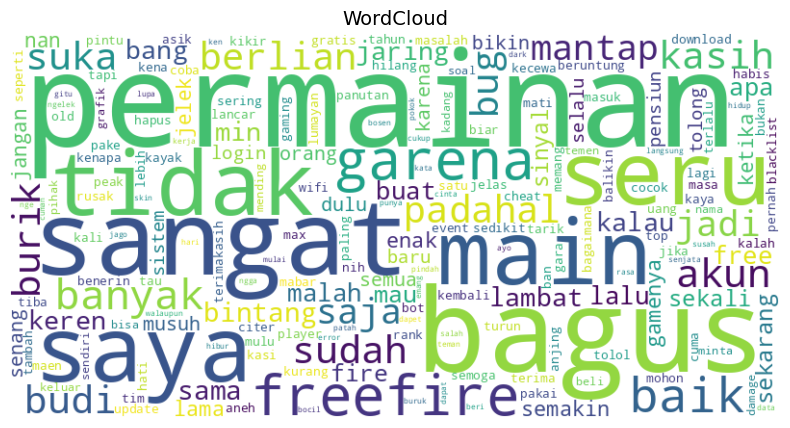

In [26]:
import pandas as pd
from nltk.tokenize import word_tokenize
from collections import OrderedDict
from nltk.util import ngrams
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re
import nltk

# Unduh resource NLTK
nltk.download('punkt')
nltk.download('punkt_tab')

# membaca file csv
df = pd.read_csv('hasil_preprocessing.csv')

if 'preprocessed' not in df.columns:
    raise ValueError("Kolom 'preprocessed' tidak ditemukan di file CSV kamu.")

# normalisasi kata
normalisasi_dict = {
    "ngeleg":"lambat","ngelag":"lambat","lag":"lambat","geme":"permainan","game":"permainan","gem":"permainan","terus":"lalu","cape":"lelah","hoky":"beruntung","susa":"sulit","nyepin":"memutar","duit":"uang","hedsot":"tembak kepala","pensi":"pensiun","enkk":"enak","diamond":"berlian","ff":"freefire","jonanya":"zonanya","abis": "habis","aj": "saja","aja": "saja","ajaa": "saja","ajg": "anjing","ajgg": "anjing","ajggg": "anjing",
    "aku": "saya","akuu": "saya","akuuu": "saya","tu":"itu","tpi":"tapi","dikit":"sedikit","baguss":"bagus","bagu":"bagus",
    "ampe": "sampai","pas":"ketika","gabisa":"tidak bisa","anj": "anjing","anjay": "anjing","anjg": "anjing","anjgg": "anjing","anjggg": "anjing","anjingg": "anjing","anjinggg": "anjing","anjingggg": "anjing",
    "anjjj": "anjing","anjjjj": "anjing","anjjjjj": "anjing","apalagi": "apalagi","apalagiii": "apalagi","apalah": "apalah","apalahhh": "apalah","asik": "asik",
    "asikk": "asik","asikkk": "asik","asikkkk": "asik","asyik": "asyik","asyikk": "asyik","asyikkk": "asyik","asyikkkk": "asyik",
    "bagusss": "bagus","bagussss": "bagus","bangettt": "sangat","bangetttt": "sangat","bgt": "sangat","bgtt": "sangat","bgttt": "sangat","bgs": "bagus","bgus": "bagus","banget":"sangat","dm":"berlian",
    "bgsx": "bagus","blm": "belum","blom": "belum","br": "baru","bwt": "buat","dah": "sudah","dg": "dengan","dgn": "dengan","dr": "dari","dsini": "disini",
    "eror": "error","g": "tidak","ga": "tidak","gak": "tidak","gk": "tidak","gpp": "tidak apa-apa","gt": "gitu","gue": "saya","gua": "saya","gw": "saya",
    "jd": "jadi","jg": "juga","k": "ke","kalo": "kalau","karna": "karena","kek": "seperti","keliatan": "terlihat","klo": "kalau","klu": "kalau",
    "kmrn": "kemarin","kn": "kan","knp": "kenapa","knapa": "kenapa","krn": "karena","lg": "lagi","lgi": "lagi","lemottt": "lemot","lemoott": "lemot",
    "makasih": "terima kasih","makasihh": "terima kasih","makasihhh": "terima kasih","makin": "semakin","mantapp": "mantap","mantappp": "mantap","mantapppp": "mantap",
    "moga": "semoga","moga2": "semoga","msh": "masih","ny": "nya","nyesel": "menyesal","nyari": "mencari","nyampe": "sampai","ok": "oke","okee": "oke",
    "okey": "oke","okeeey": "oke","parahh": "parah","parahhh": "parah","pliss": "tolong","plisss": "tolong","plis": "tolong",
    "pny": "punya","sbnernya": "sebenarnya","sdh": "sudah","siapp": "siap","siappp": "siap","hoki":"beruntung","gimana":"bagaimana",
    "skrg": "sekarang","sm": "sama","smpe": "sampai","smoga": "semoga","epep":"freefire","kalau":"jika","diamon":"berlian",
    "sprti": "seperti","sukaakk": "suka","sukaakkk": "suka","sy": "saya","tdk": "tidak","thx": "terima kasih","tq": "terima kasih","tp": "tapi",
    "trs": "terus","trus": "terus","udh": "sudah","udah": "sudah","uninstal": "uninstall","wkwk": "haha","wkwkw": "haha","wkwkwk": "haha","wkwkwkw": "haha",
    "woiii": "woi","yg": "yang","yng": "yang","yaaa": "ya","yaa": "ya","yappp": "ya","yap": "ya","yupp": "ya","yup": "ya","yaampun": "ya ampun"
}

# normalisasi
def normalisasi_kata(text):
    words = str(text).split()
    normalized = [normalisasi_dict.get(word, word) for word in words]
    return ' '.join(normalized)

df['Normalisasi'] = df['preprocessed'].apply(normalisasi_kata)
df.to_csv('hasil_normalisasi.csv', index=False)

# ============================================================
# remove duplikat
def remove_duplicates(text):
    words = str(text).split()
    unique_words = list(OrderedDict.fromkeys(words))
    return ' '.join(unique_words)

df['No_Duplikat'] = df['Normalisasi'].apply(remove_duplicates)
df.to_csv('hasil_no_duplikat.csv', index=False)

# pembersihan huruf berulang
def bersihkan_teks(text):
    words = str(text).split()
    cleaned_words = []
    for w in words:
        w = re.sub(r'(.)\1{2,}', r'\1', w)
        if len(w) >= 3:
            cleaned_words.append(w)
    return ' '.join(cleaned_words)

df['Bersih'] = df['No_Duplikat'].apply(bersihkan_teks)
df.to_csv('hasil_bersih.csv', index=False)

# tokenisasi
df['Bersih_Token'] = df['Bersih'].apply(word_tokenize)
df.to_csv('hasil_tokenisasi.csv', index=False)

# unigram, bigram, trigram
def generate_ngrams(tokens, n):
    return list(ngrams(tokens, n))

df['Unigram'] = df['Bersih_Token'].apply(lambda x: generate_ngrams(x, 1))
df['Bigram'] = df['Bersih_Token'].apply(lambda x: generate_ngrams(x, 2))
df['Trigram'] = df['Bersih_Token'].apply(lambda x: generate_ngrams(x, 3))
df.to_csv('hasil_ngram.csv', index=False)

# filter kata tidak bermakna dari bigram
stopwords = set([
    'nya','yang', 'dan', 'di', 'ke', 'dari', 'untuk', 'dengan',
    'pada', 'itu', 'ini', 'dong','sih','deh','lah','kok','ya','kan'
])

def filter_bigram(bigrams):
    return [bg for bg in bigrams if bg[0] not in stopwords and bg[1] not in stopwords]

df['Bigram_Filtered'] = df['Bigram'].apply(filter_bigram)
df.to_csv('hasil_bigram_filtered.csv', index=False)

# hapus stopword
def remove_stopwords(text):
    return ' '.join([word for word in str(text).split() if word not in stopwords])

df['Bersih_NoStop'] = df['Bersih'].apply(remove_stopwords)
df.to_csv('hasil_no_stopword.csv', index=False)

# wordcloud tanpa stopword
all_words = ' '.join(df['Bersih_NoStop'])
wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud", fontsize=14)
plt.show()

# simpan wordcloud sebagai gambar
wordcloud.to_file('wordcloud.png')

# simpan hasil
df.to_csv('hasil_final.csv', index=False)
